In [5]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

In [7]:
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,
                             log_loss)
from sklearn.ensemble import \
     (RandomForestRegressor as RF,
      GradientBoostingRegressor as GBR)

In [9]:
Carseats = load_data('Carseats')
High = np.where(Carseats.Sales > 8,
                "Yes",
                "No")

In [11]:
model = MS(Carseats.columns.drop('Sales'), intercept=False)
D = model.fit_transform(Carseats)
feature_names = list(D.columns)
X = np.asarray(D)

In [13]:
clf = DTC(criterion='entropy',
          max_depth=3,
          random_state=0)        
clf.fit(X, High)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [15]:
accuracy_score(High, clf.predict(X))

0.79

In [17]:
clf.predict_proba(X)

array([[0.81696429, 0.18303571],
       [0.03921569, 0.96078431],
       [0.7       , 0.3       ],
       [0.81696429, 0.18303571],
       [0.81696429, 0.18303571],
       [0.19444444, 0.80555556],
       [0.81696429, 0.18303571],
       [0.03921569, 0.96078431],
       [0.81696429, 0.18303571],
       [0.81696429, 0.18303571],
       [0.81696429, 0.18303571],
       [0.03921569, 0.96078431],
       [0.81696429, 0.18303571],
       [0.03921569, 0.96078431],
       [0.03921569, 0.96078431],
       [0.81696429, 0.18303571],
       [0.35294118, 0.64705882],
       [0.03921569, 0.96078431],
       [0.03921569, 0.96078431],
       [0.44444444, 0.55555556],
       [0.81696429, 0.18303571],
       [0.03921569, 0.96078431],
       [0.81696429, 0.18303571],
       [0.81696429, 0.18303571],
       [0.44444444, 0.55555556],
       [0.35294118, 0.64705882],
       [0.03921569, 0.96078431],
       [0.81696429, 0.18303571],
       [0.81696429, 0.18303571],
       [0.44444444, 0.55555556],
       [0.

In [19]:
resid_dev = np.sum(log_loss(High, clf.predict_proba(X)))
resid_dev

0.47106470626493574

[Text(0.5, 0.875, 'ShelveLoc[Good] <= 0.5\nentropy = 0.977\nsamples = 400\nvalue = [236, 164]'),
 Text(0.25, 0.625, 'Price <= 92.5\nentropy = 0.894\nsamples = 315\nvalue = [217, 98]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Income <= 57.0\nentropy = 0.887\nsamples = 46\nvalue = [14, 32]'),
 Text(0.0625, 0.125, 'entropy = 0.881\nsamples = 10\nvalue = [7, 3]'),
 Text(0.1875, 0.125, 'entropy = 0.711\nsamples = 36\nvalue = [7, 29]'),
 Text(0.375, 0.375, 'Advertising <= 13.5\nentropy = 0.804\nsamples = 269\nvalue = [203, 66]'),
 Text(0.3125, 0.125, 'entropy = 0.687\nsamples = 224\nvalue = [183, 41]'),
 Text(0.4375, 0.125, 'entropy = 0.991\nsamples = 45\nvalue = [20, 25]'),
 Text(0.75, 0.625, 'Price <= 135.0\nentropy = 0.767\nsamples = 85\nvalue = [19, 66]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'US[Yes] <= 0.5\nentropy = 0.523\nsamples = 68\nvalue = [8, 60]'),
 Text(0.5625, 0.125, 'entropy = 0.937\nsamples = 17\nvalue = [6, 11]'),
 Text(0.6875, 0.125, 'entropy = 0.

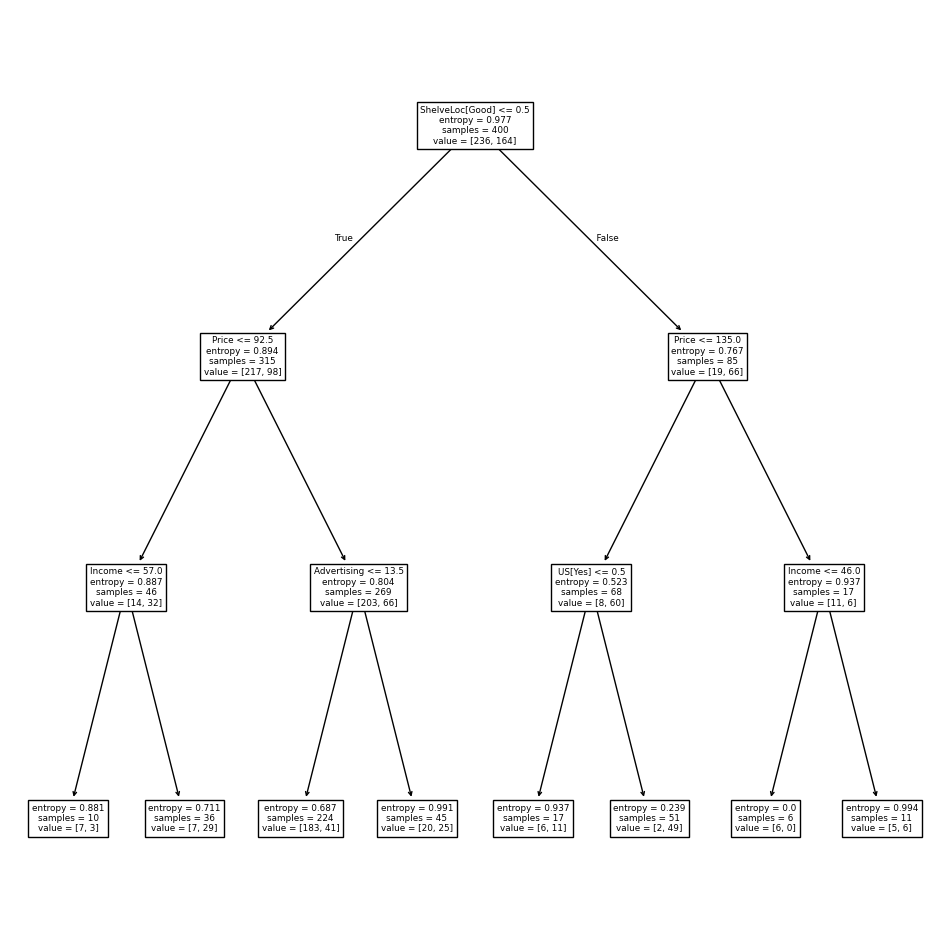

In [21]:
ax = subplots(figsize=(12,12))[1]
plot_tree(clf,
          feature_names=feature_names,
          ax=ax)

In [22]:
print(export_text(clf,
                  feature_names=feature_names,
                  show_weights=True))

|--- ShelveLoc[Good] <= 0.50
|   |--- Price <= 92.50
|   |   |--- Income <= 57.00
|   |   |   |--- weights: [7.00, 3.00] class: No
|   |   |--- Income >  57.00
|   |   |   |--- weights: [7.00, 29.00] class: Yes
|   |--- Price >  92.50
|   |   |--- Advertising <= 13.50
|   |   |   |--- weights: [183.00, 41.00] class: No
|   |   |--- Advertising >  13.50
|   |   |   |--- weights: [20.00, 25.00] class: Yes
|--- ShelveLoc[Good] >  0.50
|   |--- Price <= 135.00
|   |   |--- US[Yes] <= 0.50
|   |   |   |--- weights: [6.00, 11.00] class: Yes
|   |   |--- US[Yes] >  0.50
|   |   |   |--- weights: [2.00, 49.00] class: Yes
|   |--- Price >  135.00
|   |   |--- Income <= 46.00
|   |   |   |--- weights: [6.00, 0.00] class: No
|   |   |--- Income >  46.00
|   |   |   |--- weights: [5.00, 6.00] class: Yes



In [23]:
validation = skm.ShuffleSplit(n_splits=1,
                              test_size=200,
                              random_state=0)
results = skm.cross_validate(clf,
                             D,
                             High,
                             cv=validation)
results['test_score']

array([0.685])

In [27]:
(X_train,
 X_test,
 High_train,
 High_test) = skm.train_test_split(X,
                                   High,
                                   test_size=0.5,
                                   random_state=0)     

In [29]:
clf = DTC(criterion='entropy', random_state=0)
clf.fit(X_train, High_train)
accuracy_score(High_test, clf.predict(X_test))

0.735

In [31]:
ccp_path = clf.cost_complexity_pruning_path(X_train, High_train)
kfold = skm.KFold(10,
                  random_state=1,
                  shuffle=True)

In [33]:
ccp_path.ccp_alphas

array([0.        , 0.01622556, 0.0171946 , 0.0180482 , 0.0180482 ,
       0.01991688, 0.02012073, 0.02070855, 0.02193427, 0.0219518 ,
       0.02220877, 0.02274806, 0.02417233, 0.02588672, 0.02714959,
       0.02735525, 0.02900052, 0.02906078, 0.03209543, 0.04499252,
       0.06236632, 0.10024835])

In [35]:
grid = skm.GridSearchCV(clf,
                        {'ccp_alpha': ccp_path.ccp_alphas},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy')
grid.fit(X_train, High_train)
grid.best_score_

0.685

[Text(0.4345703125, 0.95, 'Price <= 94.5\nentropy = 0.977\nsamples = 200\nvalue = [118, 82]'),
 Text(0.1875, 0.85, 'CompPrice <= 118.5\nentropy = 0.769\nsamples = 40\nvalue = [9, 31]'),
 Text(0.31103515625, 0.8999999999999999, 'True  '),
 Text(0.15625, 0.75, 'Price <= 86.5\nentropy = 0.894\nsamples = 29\nvalue = [9, 20]'),
 Text(0.09375, 0.65, 'Income <= 60.0\nentropy = 0.523\nsamples = 17\nvalue = [2, 15]'),
 Text(0.0625, 0.55, 'Advertising <= 5.0\nentropy = 0.971\nsamples = 5\nvalue = [2, 3]'),
 Text(0.03125, 0.45, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.09375, 0.45, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.125, 0.55, 'entropy = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.21875, 0.65, 'Population <= 212.5\nentropy = 0.98\nsamples = 12\nvalue = [7, 5]'),
 Text(0.1875, 0.55, 'entropy = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.25, 0.55, 'Income <= 36.5\nentropy = 0.954\nsamples = 8\nvalue = [3, 5]'),
 Text(0.21875, 0.45, 'entropy = 0.0\nsamples = 3\nval

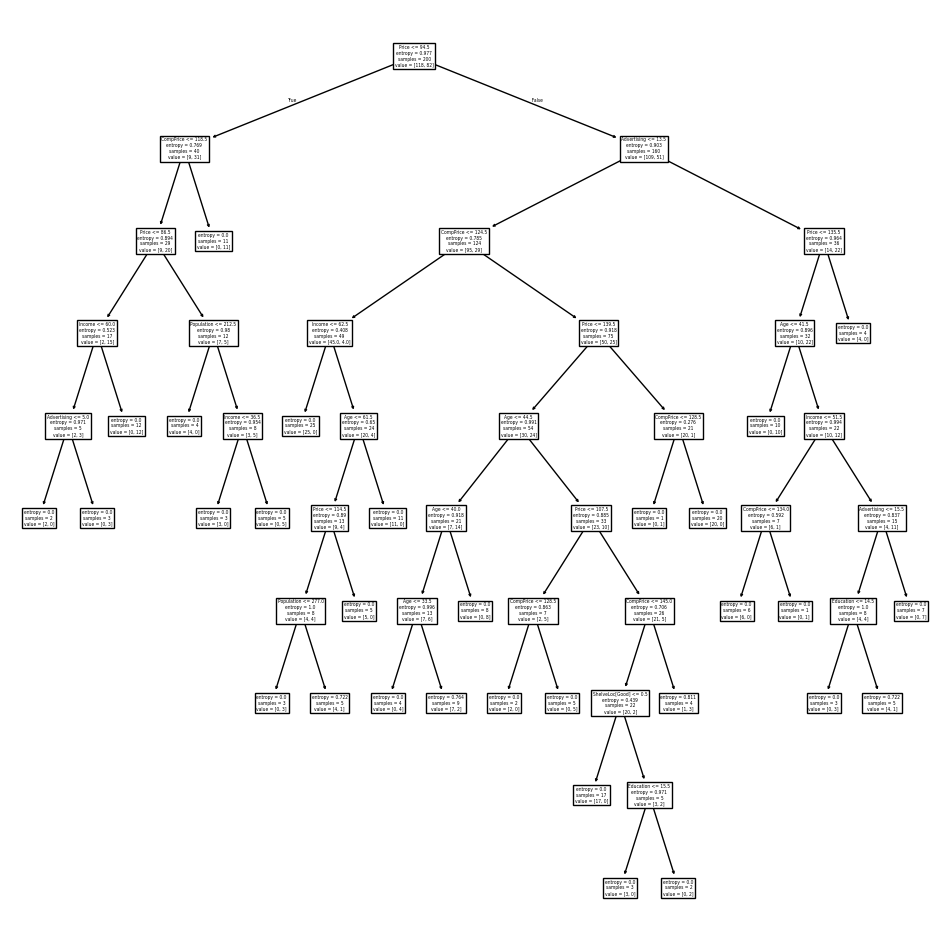

In [36]:
ax = subplots(figsize=(12, 12))[1]
best_ = grid.best_estimator_
plot_tree(best_,
          feature_names=feature_names,
          ax=ax)

In [37]:
best_.tree_.n_leaves

30

In [39]:
print(accuracy_score(High_test,
                     best_.predict(X_test)))
confusion = confusion_table(best_.predict(X_test),
                            High_test)
confusion

0.72


Truth,No,Yes
Predicted,,
No,94,32
Yes,24,50


In [40]:
Boston = load_data("Boston")
model = MS(Boston.columns.drop('medv'), intercept=False)
D = model.fit_transform(Boston)
feature_names = list(D.columns)
X = np.asarray(D)

In [41]:
(X_train,
 X_test,
 y_train,
 y_test) = skm.train_test_split(X,
                                Boston['medv'],
                                test_size=0.3,
                                random_state=0)

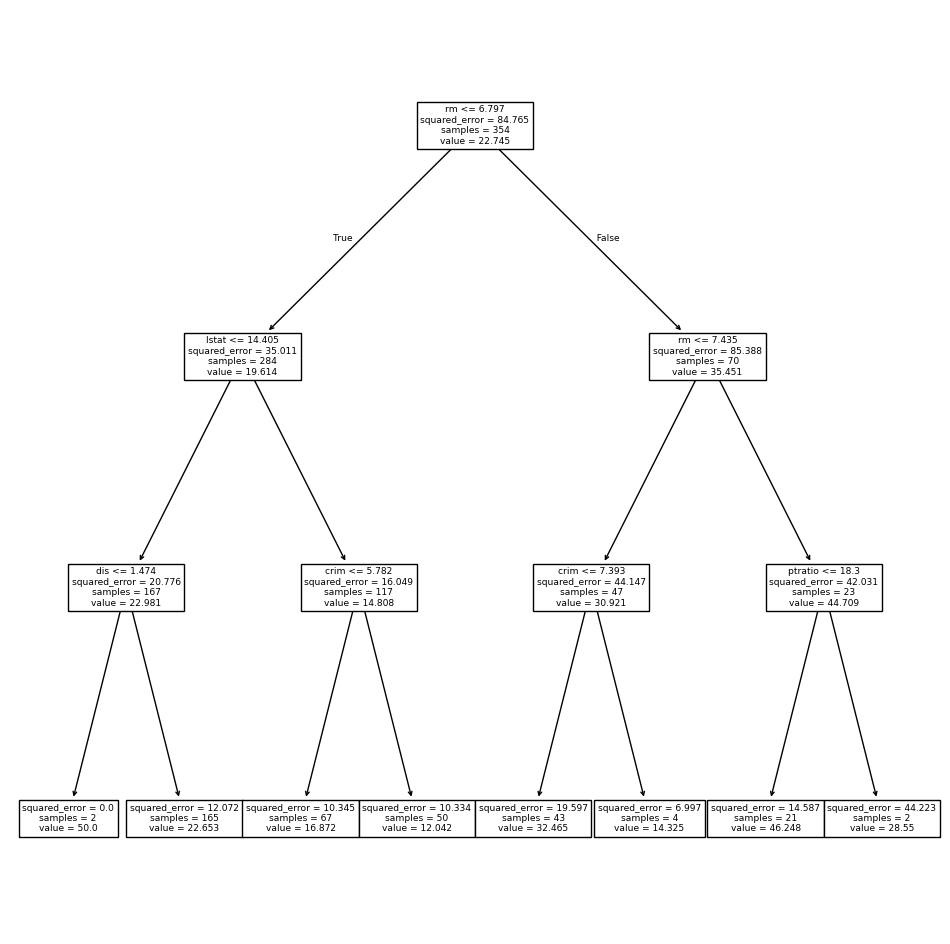

In [42]:
reg = DTR(max_depth=3)
reg.fit(X_train, y_train)
ax = subplots(figsize=(12,12))[1]
plot_tree(reg,
          feature_names=feature_names,
          ax=ax);

In [43]:
ccp_path = reg.cost_complexity_pruning_path(X_train, y_train)
kfold = skm.KFold(5,
                  shuffle=True,
                  random_state=10)
grid = skm.GridSearchCV(reg,
                        {'ccp_alpha': ccp_path.ccp_alphas},
                        refit=True,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
G = grid.fit(X_train, y_train)

In [44]:
best_ = grid.best_estimator_
np.mean((y_test - best_.predict(X_test))**2)

28.06985754975404

[Text(0.5, 0.875, 'rm <= 6.797\nsquared_error = 84.765\nsamples = 354\nvalue = 22.745'),
 Text(0.25, 0.625, 'lstat <= 14.405\nsquared_error = 35.011\nsamples = 284\nvalue = 19.614'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'dis <= 1.474\nsquared_error = 20.776\nsamples = 167\nvalue = 22.981'),
 Text(0.0625, 0.125, 'squared_error = 0.0\nsamples = 2\nvalue = 50.0'),
 Text(0.1875, 0.125, 'squared_error = 12.072\nsamples = 165\nvalue = 22.653'),
 Text(0.375, 0.375, 'crim <= 5.782\nsquared_error = 16.049\nsamples = 117\nvalue = 14.808'),
 Text(0.3125, 0.125, 'squared_error = 10.345\nsamples = 67\nvalue = 16.872'),
 Text(0.4375, 0.125, 'squared_error = 10.334\nsamples = 50\nvalue = 12.042'),
 Text(0.75, 0.625, 'rm <= 7.435\nsquared_error = 85.388\nsamples = 70\nvalue = 35.451'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'crim <= 7.393\nsquared_error = 44.147\nsamples = 47\nvalue = 30.921'),
 Text(0.5625, 0.125, 'squared_error = 19.597\nsamples = 43\nvalue = 32.465'),
 Text

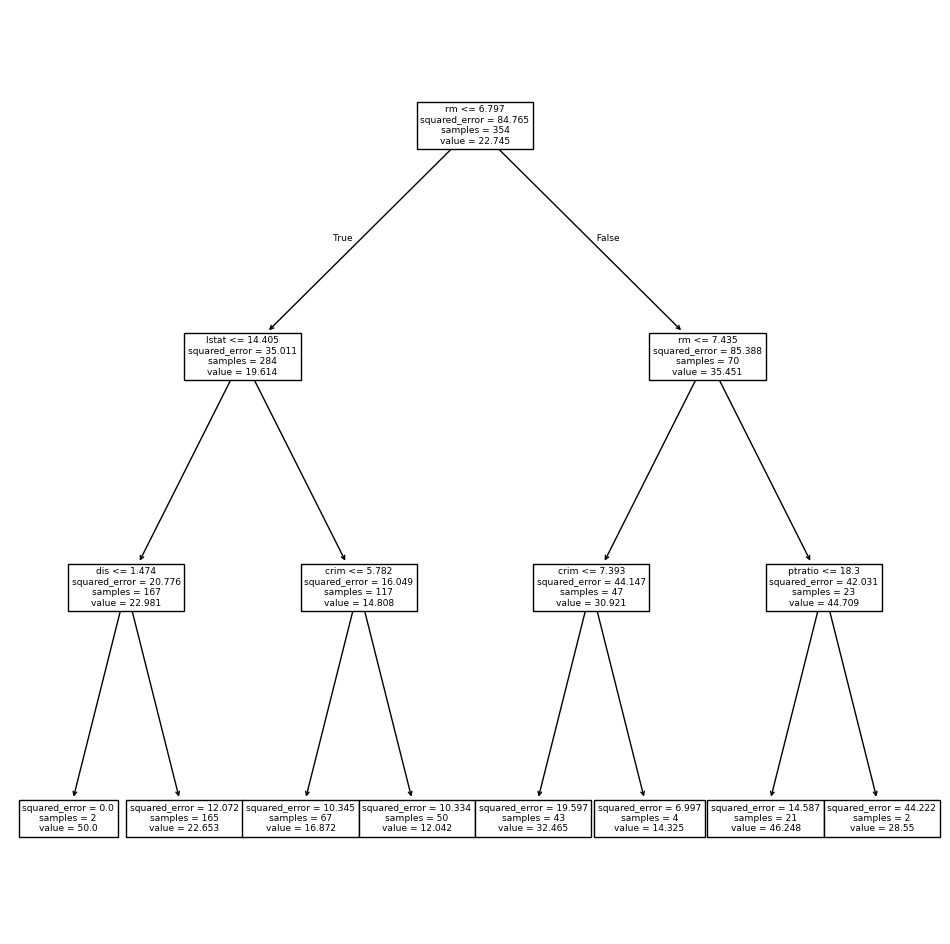

In [45]:
ax = subplots(figsize=(12,12))[1]
plot_tree(G.best_estimator_,
          feature_names=feature_names,
          ax=ax)

In [51]:
bag_boston = RF(max_features=X_train.shape[1], random_state=0)
bag_boston.fit(X_train, y_train)

RandomForestRegressor(max_features=12, random_state=0)

14.634700151315787

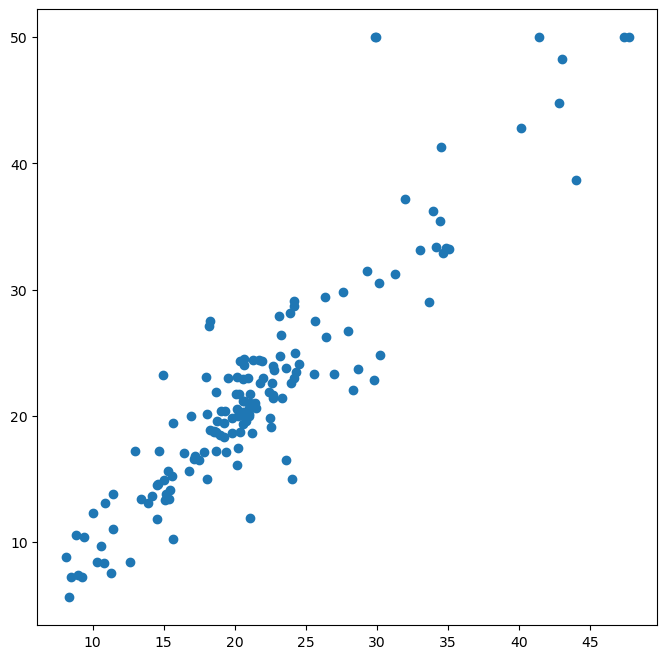

In [52]:
ax = subplots(figsize=(8,8))[1]
y_hat_bag = bag_boston.predict(X_test)
ax.scatter(y_hat_bag, y_test)
np.mean((y_test - y_hat_bag)**2)

In [53]:
bag_boston = RF(max_features=X_train.shape[1],
                n_estimators=500,
                random_state=0).fit(X_train, y_train)
y_hat_bag = bag_boston.predict(X_test)
np.mean((y_test - y_hat_bag)**2)

14.605662565263161

In [57]:
RF_boston = RF(max_features=6,
               random_state=0).fit(X_train, y_train)
y_hat_RF = RF_boston.predict(X_test)
np.mean((y_test - y_hat_RF)**2)

20.04276446710527

In [58]:
feature_imp = pd.DataFrame(
    {'importance':RF_boston.feature_importances_},
    index=feature_names)
feature_imp.sort_values(by='importance', ascending=False)

,importance
lstat,0.356203
rm,0.332163
ptratio,0.067270
crim,0.055404
indus,0.053851
dis,0.041582
nox,0.035225
tax,0.025355
age,0.021506
rad,0.004784


In [59]:
boost_boston = GBR(n_estimators=5000,
                   learning_rate=0.001,
                   max_depth=3,
                   random_state=0)
boost_boston.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.001, n_estimators=5000,
                          random_state=0)

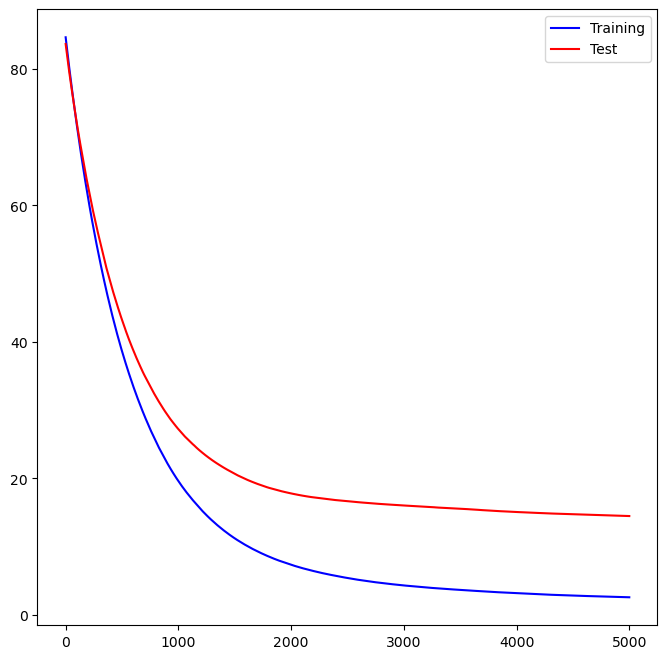

In [63]:
test_error = np.zeros_like(boost_boston.train_score_)
for idx, y_ in enumerate(boost_boston.staged_predict(X_test)):
   test_error[idx] = np.mean((y_test - y_)**2)

plot_idx = np.arange(boost_boston.train_score_.shape[0])
ax = subplots(figsize=(8,8))[1]
ax.plot(plot_idx,
        boost_boston.train_score_,
        'b',
        label='Training')
ax.plot(plot_idx,
        test_error,
        'r',
        label='Test')
ax.legend();

In [64]:
y_hat_boost = boost_boston.predict(X_test);
np.mean((y_test - y_hat_boost)**2)

14.481405918831591

In [68]:
boost_boston = GBR(n_estimators=5000,
                   learning_rate=0.2,
                   max_depth=3,
                   random_state=0)
boost_boston.fit(X_train,
                 y_train)
y_hat_boost = boost_boston.predict(X_test);
np.mean((y_test - y_hat_boost)**2)

14.501514553719565

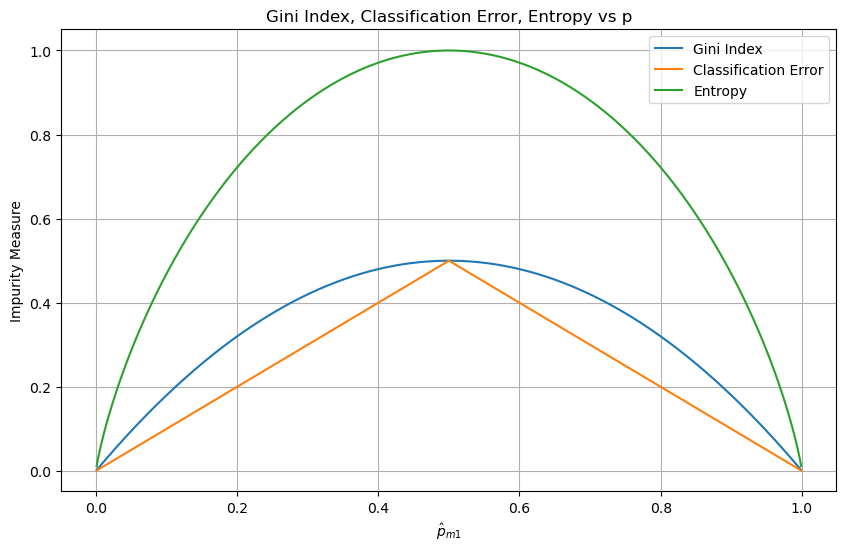

In [75]:
p = np.linspace(0.001, 0.999, 1000)  
gini = 2 * p * (1 - p)
classification_error = 1 - np.maximum(p, 1 - p)
entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

plt.figure(figsize=(10, 6))
plt.plot(p, gini, label='Gini Index')
plt.plot(p, classification_error, label='Classification Error')
plt.plot(p, entropy, label='Entropy')
plt.xlabel(r'$\hat{p}_{m1}$')
plt.ylabel('Impurity Measure')
plt.title('Gini Index, Classification Error, Entropy vs p')
plt.legend()
plt.grid(True)
plt.show()

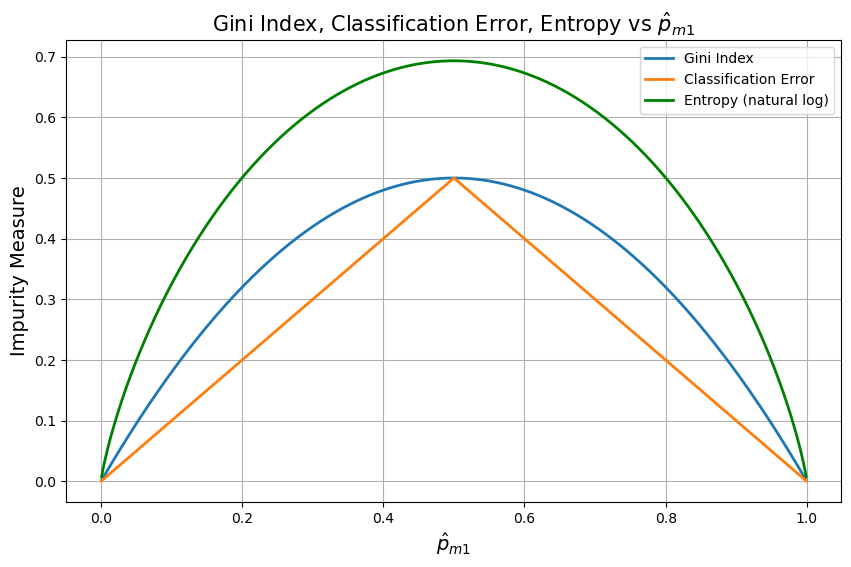

In [77]:
p = np.linspace(0.001, 0.999, 1000)

gini = 2 * p * (1 - p)
classification_error = 1 - np.maximum(p, 1 - p)
entropy_ln = -p * np.log(p) - (1 - p) * np.log(1 - p)  

plt.figure(figsize=(10, 6))
plt.plot(p, gini, label='Gini Index', linewidth=2)
plt.plot(p, classification_error, label='Classification Error', linewidth=2)
plt.plot(p, entropy_ln, label='Entropy (natural log)', linewidth=2, color='green')
plt.xlabel(r'$\hat{p}_{m1}$', fontsize=14)
plt.ylabel('Impurity Measure', fontsize=14)
plt.title('Gini Index, Classification Error, Entropy vs $\\hat{p}_{m1}$', fontsize=15)
plt.legend()
plt.grid(True)
plt.show()

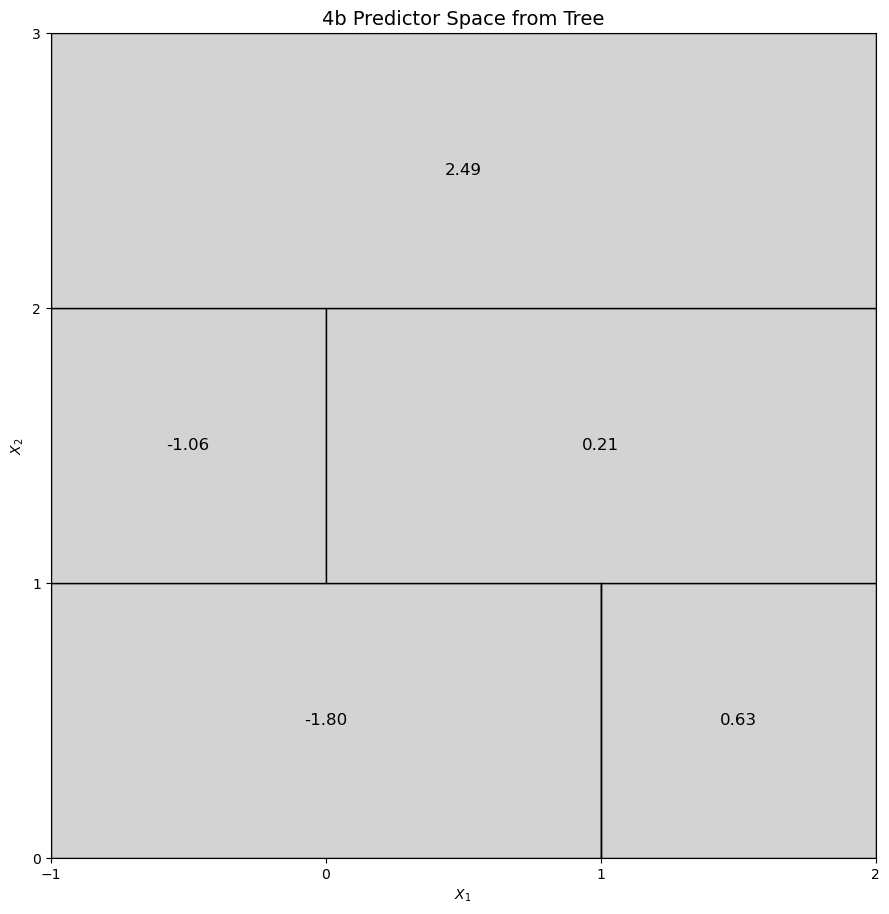

In [87]:
import matplotlib.patches as patches



fig, ax = plt.subplots(figsize=(9, 10))
ax.set_title('4b Predictor Space from Tree', fontsize=14)

# 아래: X2 ∈ [0, 1)
ax.add_patch(patches.Rectangle((-1, 0), 2, 1, edgecolor='black', facecolor='lightgray'))  # X1 < 1 → -1.80
ax.text(0, 0.5, '-1.80', ha='center', va='center', fontsize=12)
ax.add_patch(patches.Rectangle((1, 0), 1, 1, edgecolor='black', facecolor='lightgray'))  # X1 ≥ 1 → 0.63
ax.text(1.5, 0.5, '0.63', ha='center', va='center', fontsize=12)

# 중간: X2 ∈ [1, 2)
ax.add_patch(patches.Rectangle((-1, 1), 1, 1, edgecolor='black', facecolor='lightgray'))  # X1 < 0 → -1.06
ax.text(-0.5, 1.5, '-1.06', ha='center', va='center', fontsize=12)
ax.add_patch(patches.Rectangle((0, 1), 2, 1, edgecolor='black', facecolor='lightgray'))  # X1 ≥ 0 → 0.21
ax.text(1.0, 1.5, '0.21', ha='center', va='center', fontsize=12)

# 상단: X2 ≥ 2
ax.add_patch(patches.Rectangle((-1, 2), 3, 1, edgecolor='black', facecolor='lightgray'))  # 전체 X1 → 2.49
ax.text(0.5, 2.5, '2.49', ha='center', va='center', fontsize=12)

# 분할선 (X1 = 1)
ax.plot([1, 1], [0, 1], color='black', linewidth=1)

# 축 설정
ax.set_xlim(-1, 2)
ax.set_ylim(0, 3)
ax.set_xticks([-1, 0, 1, 2])
ax.set_yticks([0, 1, 2, 3])
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')
ax.set_aspect('equal', adjustable='box')
ax.grid(False)

plt.tight_layout()
plt.show()

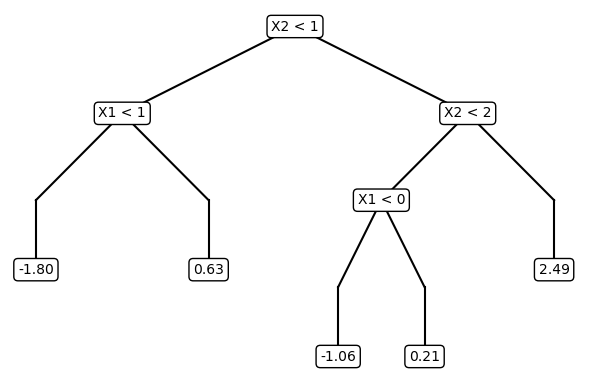

In [91]:

fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('off')  # 축 없애기

# 노드 좌표 정의
nodes = {
    "root": (0.5, 1.0),
    "x2<1_L": (0.25, 0.75),
    "x2<1_R": (0.75, 0.75),
    "x1<1_LL": (0.125, 0.5),
    "x1<1_LR": (0.375, 0.5),
    "x2<2_L": (0.625, 0.5),
    "x2<2_R": (0.875, 0.5),
    "x1<0_LL": (0.5625, 0.25),
    "x1<0_LR": (0.6875, 0.25),
    "leaf1": (0.125, 0.3),   # -1.80
    "leaf2": (0.375, 0.3),   # 0.63
    "leaf3": (0.5625, 0.05), # -1.06
    "leaf4": (0.6875, 0.05), # 0.21
    "leaf5": (0.875, 0.3),   # 2.49
}

# 연결선 그리기
lines = [
    ("root", "x2<1_L"), ("root", "x2<1_R"),
    ("x2<1_L", "x1<1_LL"), ("x2<1_L", "x1<1_LR"),
    ("x1<1_LL", "leaf1"), ("x1<1_LR", "leaf2"),
    ("x2<1_R", "x2<2_L"), ("x2<1_R", "x2<2_R"),
    ("x2<2_L", "x1<0_LL"), ("x2<2_L", "x1<0_LR"),
    ("x1<0_LL", "leaf3"), ("x1<0_LR", "leaf4"),
    ("x2<2_R", "leaf5"),
]

for parent, child in lines:
    x_vals = [nodes[parent][0], nodes[child][0]]
    y_vals = [nodes[parent][1], nodes[child][1]]
    ax.plot(x_vals, y_vals, 'k-')

# 노드 텍스트
texts = {
    "root": "X2 < 1",
    "x2<1_L": "X1 < 1",
    "x2<1_R": "X2 < 2",
    "x1<1_LL": "", "x1<1_LR": "",
    "x2<2_L": "X1 < 0",
    "x2<2_R": "",
    "x1<0_LL": "", "x1<0_LR": "",
    "leaf1": "-1.80",
    "leaf2": "0.63",
    "leaf3": "-1.06",
    "leaf4": "0.21",
    "leaf5": "2.49",
}

for node, (x, y) in nodes.items():
    text = texts.get(node, "")
    if text:
        ax.text(x, y, text, ha='center', va='center',
                bbox=dict(boxstyle="round", fc="white"))

plt.tight_layout()
plt.show()

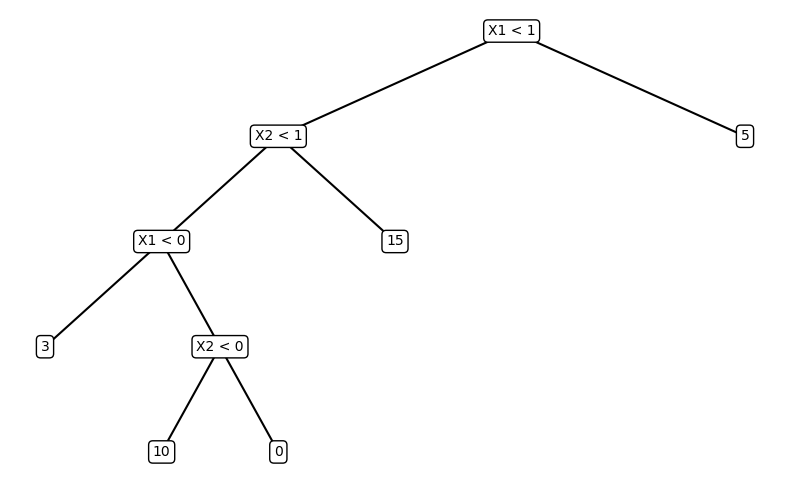

In [93]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.axis('off')  # 축 없애기

# 노드 좌표 정의
nodes = {
    "root": (0.5, 1.0),        # X1 < 1
    "x2<1": (0.3, 0.8),        # X2 < 1
    "leaf5": (0.7, 0.8),       # 5
    "x1<0": (0.2, 0.6),        # X1 < 0
    "leaf15": (0.4, 0.6),      # 15
    "leaf3": (0.1, 0.4),       # 3
    "x2<0": (0.25, 0.4),       # X2 < 0
    "leaf10": (0.2, 0.2),      # 10
    "leaf0": (0.3, 0.2),       # 0
}

# 연결선 정의
lines = [
    ("root", "x2<1"), ("root", "leaf5"),
    ("x2<1", "x1<0"), ("x2<1", "leaf15"),
    ("x1<0", "leaf3"), ("x1<0", "x2<0"),
    ("x2<0", "leaf10"), ("x2<0", "leaf0"),
]

# 선 그리기
for parent, child in lines:
    x_vals = [nodes[parent][0], nodes[child][0]]
    y_vals = [nodes[parent][1], nodes[child][1]]
    ax.plot(x_vals, y_vals, 'k-')

# 텍스트 라벨
texts = {
    "root": "X1 < 1",
    "x2<1": "X2 < 1",
    "leaf5": "5",
    "x1<0": "X1 < 0",
    "leaf15": "15",
    "leaf3": "3",
    "x2<0": "X2 < 0",
    "leaf10": "10",
    "leaf0": "0",
}

for node, (x, y) in nodes.items():
    ax.text(x, y, texts[node], ha='center', va='center',
            bbox=dict(boxstyle="round", fc="white"))

plt.tight_layout()
plt.show()